## Notebook for plotting flux time series and calculating annual GHG balances for the Tikkasalo et al. (2025) article
Tikkasalo, O.-P., Peltola, O., Alekseychik, P., Heikkinen, J., Launiainen, S., Lehtonen, A., Li, Q., Martinez-García, E., Peltoniemi, M., Salovaara, P., Tuominen, V., and Mäkipää, R.: Eddy covariance fluxes of CO2, CH4 and N2O on a drained peatland forest after clearcutting, EGUsphere [preprint], https://doi.org/10.5194/egusphere-2024-1994, 2024

In [2]:
import datetime as dt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

import utils

filepath = 'data/'

Loading data

In [3]:
ec = utils.load_Ran_gapfilled_ec_data(filepath, [2022])
variables = list(ec.data_vars)

cols = []
for var in variables:
    cols.append(ec[var].to_series())

ecdf = pd.concat(cols,axis=1)
ecdf['time'] = ec.coords['time'].to_series()
ecdf = ecdf.set_index('time')
ecdf.index = ecdf.index.round('1s')
del ec

In [4]:
filein = filepath + "TA_soil_moisture_2022.csv"
dftheta = pd.read_csv(filein,index_col='time',parse_dates=True)

In [5]:
ecdf = ecdf.join(dftheta)

Time period to be analysed

In [6]:
ts = dt.datetime(2022,1,1,0,0,0)
te = dt.datetime(2022,12,31,23,59,59)

Adjusting figure plotting style

In [7]:
sns.set_theme(style='ticks',context='paper')
# sns.set_palette(cmp.batlow(np.linspace(0,1,500)))
cm = 1/2.54


months = mdates.MonthLocator(interval=1)

days = mdates.DayLocator(interval=5)
snames = {'FI-Ran':'Ränskälänkorpi'}
ylabels = dict()
ylabels['co2_flux_final_gf_ensemble'] = 'NEE ($\mu$mol m$^{-2}$ s$^{-1}$)'
ylabels['GPP_gf_ensemble_NT'] = 'GPP ($\mu$mol m$^{-2}$ s$^{-1}$)'
ylabels['Reco_gf_ensemble_NT'] = 'Reco ($\mu$mol m$^{-2}$ s$^{-1}$)'
ylabels['ch4_flux_final_gf_ensemble'] = 'CH$_4$ flux (nmol m$^{-2}$ s$^{-1}$)'
ylabels['n2o_flux_final_gf_ensemble'] = 'N$_2$O flux (nmol m$^{-2}$ s$^{-1}$)'
ylabels['TA_1_1_1'] = 'Air temperature ($\circ$C)'
ylabels2 = dict()
ylabels2['co2_flux_final_gf_ensemble'] = 'Cumulative flux (kg(CO$_2$) ha$^{-1}$ yr$^{-1}$)'
ylabels2['GPP_gf_ensemble_NT'] = 'Cumulative flux (kg(CO$_2$) ha$^{-1}$ yr$^{-1}$)'
ylabels2['Reco_gf_ensemble_NT'] = 'Cumulative flux (kg(CO$_2$) ha$^{-1}$ yr$^{-1}$)'
ylabels2['ch4_flux_final_gf_ensemble'] = 'Cumulative flux (kg(CO$_2$) ha$^{-1}$ yr$^{-1}$)'
ylabels2['n2o_flux_final_gf_ensemble'] = 'Cumulative flux (kg(CO$_2$) ha$^{-1}$ yr$^{-1}$)'
ylims = dict()
ylims['co2_flux_final_gf_ensemble'] = {'FI-Ran':[-5.5,15]}
ylims['GPP_gf_ensemble_NT'] = {'FI-Ran':[-0.5,15]}
ylims['Reco_gf_ensemble_NT'] = {'FI-Ran':[-0.5,20]}
ylims['ch4_flux_final_gf_ensemble'] = {'FI-Ran':[-5,15]}
ylims['n2o_flux_final_gf_ensemble'] = {'FI-Ran':[-0.2,11]}
ylims2 = dict()
ylims2['co2_flux_final_gf_ensemble'] = {'FI-Ran':[-5.5,10]}
ylims2['ch4_flux_final_gf_ensemble'] = {'FI-Ran':[-0.7,6]}
ylims2['n2o_flux_final_gf_ensemble'] = {'FI-Ran':[-0.1,6]}
ylims2['TA_1_1_1'] = {'FI-Ran':[-25,30]}

clrs = dict()
clrs['co2_flux_final_gf_ensemble'] = (0.18206, 0.34699, 0.167337, 1.0)
clrs['GPP_gf_ensemble_NT'] = (0.507361, 0.531457, 4.3e-05, 1.0)
clrs['Reco_gf_ensemble_NT'] = (0.897308, 0.797057, 0.459016, 1.0)
clrs['ch4_flux_final_gf_ensemble'] = (0.7490196078431373, 0.5058823529411764, 0.17647058823529413, 1.0)
clrs['n2o_flux_final_gf_ensemble'] = (0.5200962739223556, 0.6635739143403039, 0.768051194033441, 1.0)


annual_unc = ['RF','XGB','kNN']


GWP100_n2o = 273 #kgCO2eq/kgN2O
GWP100_ch4 = 27 #kgCO2eq/kgCH4
# conversions from mumol m-2 s-1 to kg(CO2-eq) ha-1 yr-1
coef = dict()
coef['n2o_flux_final_gf_ensemble'] = 60*30*1e-6*0.04401*1e4*GWP100_n2o
coef['co2_flux_final_gf_ensemble'] = 60*30*1e-6*0.04401*1e4
coef['GPP_gf_ensemble_NT'] = 60*30*1e-6*0.04401*1e4
coef['Reco_gf_ensemble_NT'] = 60*30*1e-6*0.04401*1e4
coef['ch4_flux_final_gf_ensemble'] = 60*30*1e-6*0.01604*1e4*GWP100_ch4


sID = 'FI-Ran'

Data coverage

In [8]:
var = 'co2_flux_final_gap'
print('CO2: ' + str(int((ecdf[var]==0).sum()/len(ecdf)*100)) + '%')
var = 'ch4_flux_final_gap'
print('CH4: ' + str(int((ecdf[var]==0).sum()/len(ecdf)*100)) + '%')
var = 'n2o_flux_final_gap'
print('N2O: ' + str(int((ecdf[var]==0).sum()/len(ecdf)*100)) + '%')

CO2: 64%
CH4: 59%
N2O: 59%


30-min flux time series

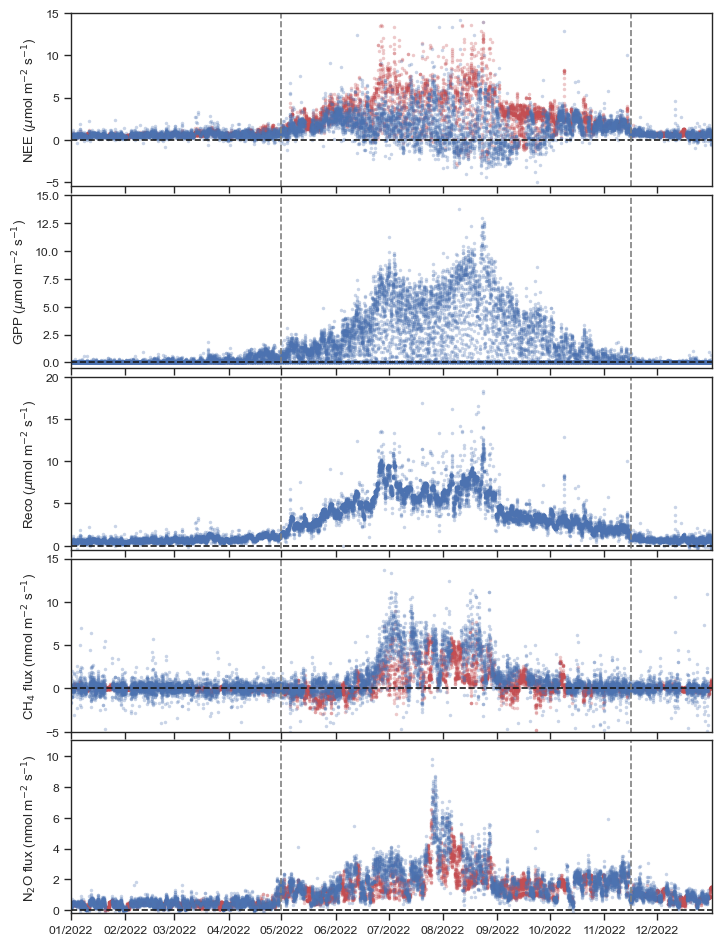

In [9]:
mosaic = [
        ["co2_flux_final_gf_ensemble"],
        ["GPP_gf_ensemble_NT"],
        ["Reco_gf_ensemble_NT"],
        ["ch4_flux_final_gf_ensemble"],
        ["n2o_flux_final_gf_ensemble"]
    ]
fig, ax = plt.subplot_mosaic(mosaic,
    height_ratios=[1,1,1,1,1],gridspec_kw={'hspace':0.05})
# fig, ax = plt.subplot_mosaic(mosaic,
#     height_ratios=[1,1,1,1,1,1,1,1,1],gridspec_kw={'hspace':0.05})
fig.set_size_inches(21*cm, 29.7*cm,forward=True)

for gas in ['GPP_gf_ensemble_NT','co2_flux_final_gf_ensemble','Reco_gf_ensemble_NT','ch4_flux_final_gf_ensemble','n2o_flux_final_gf_ensemble']:
    
    # fig, ax = plt.subplot_mosaic('A')
    # fig.set_size_inches(21*cm, 10*cm,forward=True)

    if (gas=='ch4_flux_final_gf_ensemble') | (gas=='n2o_flux_final_gf_ensemble'):
        datplot = ecdf[gas]*1e3
    else:
        datplot = ecdf[gas].copy()
    
    if (gas!='GPP_gf_ensemble_NT') & (gas!='Reco_gf_ensemble_NT'):
        ax[gas].plot(datplot[ecdf[gas.replace('gf_ensemble','gap')]==1],'k.',alpha=0.3,markersize=5,markerfacecolor='r',markeredgecolor="none")
        ax[gas].plot(datplot[ecdf[gas.replace('gf_ensemble','gap')]==0],'k.',alpha=0.3,markersize=5,markerfacecolor='b',markeredgecolor="none")
    else:
        ax[gas].plot(datplot,'k.',alpha=0.3,markersize=5,markerfacecolor='b',markeredgecolor="none")

    ax[gas].plot([ts,te],[0,0],'k--')
    yrs = datplot.index.year.unique()
    for yr in yrs:
        ax[gas].plot([dt.datetime(yr,1,1),dt.datetime(yr,1,1)],[-1e5,1e5],'k--')

    ax[gas].plot([dt.datetime(2022,5,1),dt.datetime(2022,5,1)],[-1e5,1e5],'--',color='gray')
    ax[gas].plot([dt.datetime(2022,11,16),dt.datetime(2022,11,16)],[-1e5,1e5],'--',color='gray')

    ax[gas].set_ylim(ylims[gas][sID])
    # ax['A'].set_xlim([ts,te])
    ax[gas].set_xlim([ts,te])
    ax[gas].set_ylabel(ylabels[gas])
    if gas=='n2o_flux_final_gf_ensemble':
        ax[gas].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
        labels = ax[gas].get_xticklabels()
        # plt.setp(labels, rotation=45)
    else:
        ax[gas].xaxis.set_major_formatter(ticker.NullFormatter())


    ax[gas].xaxis.set_major_locator(months)
    # plt.text(.03, .95, snames[sID], ha='left', va='top', transform=ax['A'].transAxes,backgroundcolor='w')

plt.show()
    
# fig.savefig('all_gases_30min_time_series.png', dpi=200,bbox_inches='tight')

Calculation of daily statistics

In [10]:
daily_means = ecdf.groupby(pd.Grouper(freq='1D')).mean()
daily_std = ecdf.groupby(pd.Grouper(freq='1D')).std()


Time series with daily means + cumulative sums

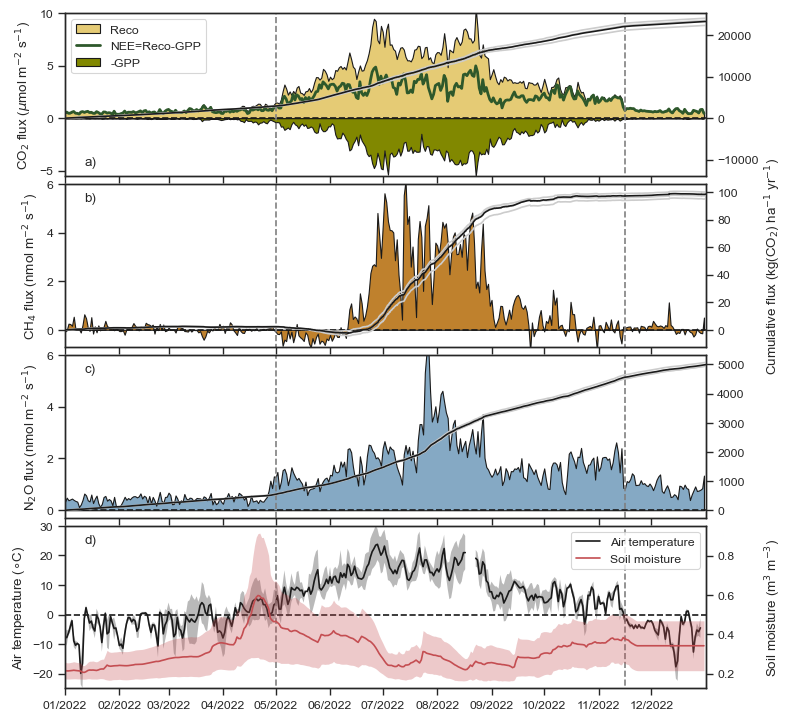

In [11]:

mosaic = [
        ["co2_flux_final_gf_ensemble"],
        ["ch4_flux_final_gf_ensemble"],
        ["n2o_flux_final_gf_ensemble"],
        ["TA_1_1_1"]
    ]
fig, ax = plt.subplot_mosaic(mosaic,
    height_ratios=[1,1,1,1],gridspec_kw={'hspace':0.05})
# fig, ax = plt.subplot_mosaic(mosaic,
#     height_ratios=[1,1,1,1,1,1,1,1,1],gridspec_kw={'hspace':0.05})
fig.set_size_inches(21*cm, 29.7*3/4*cm,forward=True)
indx = ord('a')
for gas in ['co2_flux_final_gf_ensemble','ch4_flux_final_gf_ensemble','n2o_flux_final_gf_ensemble','TA_1_1_1']:
    
    # fig, ax = plt.subplot_mosaic('A')
    # fig.set_size_inches(21*cm, 10*cm,forward=True)

    if (gas=='ch4_flux_final_gf_ensemble') | (gas=='n2o_flux_final_gf_ensemble'):
        datplot = daily_means[gas]*1e3
    else:
        datplot = daily_means[gas].copy()
    
    if (gas=='co2_flux_final_gf_ensemble'):
        
        ax[gas].stackplot(daily_means.index,daily_means['Reco_gf_ensemble_NT'],labels=['Reco'],color=clrs['Reco_gf_ensemble_NT'],edgecolor='k')
        # ax[gas].stackplot(daily_means.index,daily_means[gas],labels=['NEE'],color=clrs[gas],edgecolor='k')
        ax[gas].plot(daily_means.index,daily_means[gas],label='NEE=Reco-GPP',color=clrs[gas],linewidth=2)
        ax[gas].stackplot(daily_means.index,-daily_means['GPP_gf_ensemble_NT'],labels=['-GPP'],color=clrs['GPP_gf_ensemble_NT'],edgecolor='k')
        ax[gas].legend(loc='upper left')
        
        ax[gas].set_ylabel('CO$_2$ flux ($\mu$mol m$^{-2}$ s$^{-1}$)')
        
        plt.text(.03, .05, chr(indx)+')', ha='left', va='bottom', transform=ax[gas].transAxes,backgroundcolor='w')
    elif (gas=='TA_1_1_1'):
        # ax[gas].errorbar(daily_means.index,daily_means[gas],yerr=daily_std[gas])
        ax[gas].fill_between(daily_means.index,daily_means[gas]-daily_std[gas],daily_means[gas]+daily_std[gas],linewidth=0,color='k',alpha=0.3)
        ax[gas].plot(daily_means.index,daily_means[gas],'k-',label='Air temperature')
        ax[gas].set_ylabel(ylabels[gas])
        
        plt.text(.03, .95, chr(indx)+')', ha='left', va='top', transform=ax[gas].transAxes,backgroundcolor='w')
    else:
        ax[gas].stackplot(daily_means.index,datplot,color=clrs[gas],edgecolor='k')
        ax[gas].set_ylabel(ylabels[gas])
        plt.text(.03, .95, chr(indx)+')', ha='left', va='top', transform=ax[gas].transAxes,backgroundcolor='w')
        
        # ax[gas].plot(datplot,'k.',alpha=0.3,markersize=5,markerfacecolor='b',markeredgecolor="none")

    ax[gas].plot([ts,te],[0,0],'k--')
    yrs = datplot.index.year.unique()
    for yr in yrs:
        ax[gas].plot([dt.datetime(yr,1,1),dt.datetime(yr,1,1)],[-1e5,1e5],'k--')

    ax[gas].plot([dt.datetime(2022,5,1),dt.datetime(2022,5,1)],[-1e5,1e5],'--',color='gray')
    ax[gas].plot([dt.datetime(2022,11,16),dt.datetime(2022,11,16)],[-1e5,1e5],'--',color='gray')

    ax[gas].set_ylim(ylims2[gas][sID])
    # ax['A'].set_xlim([ts,te])
    ax[gas].set_xlim([ts,te])
    if gas=='TA_1_1_1':
        ax[gas].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
        labels = ax[gas].get_xticklabels()
        # plt.setp(labels, rotation=45)
    else:
        ax[gas].xaxis.set_major_formatter(ticker.NullFormatter())


    ax[gas].xaxis.set_major_locator(months)


    if gas!='TA_1_1_1':
        twin1 = ax[gas].twinx()
        for unc_var in annual_unc:
            twin1.plot(ecdf.loc[(ecdf.index>=ts) & (ecdf.index<te),gas.replace('ensemble',unc_var)].cumsum()*coef[gas],'-',color=(0.8,0.8,0.8,1))
        twin1.plot(ecdf.loc[(ecdf.index>=ts) & (ecdf.index<te),gas].cumsum()*coef[gas],'k-')

        if gas=='ch4_flux_final_gf_ensemble':
            twin1.set_ylabel(ylabels2[gas])
            twin1.yaxis.set_label_coords(1.09,0.5)
        # twin1.set_ylim(top=7.5)
        # if figure_context=='talk':
        #     twin1.set_yticks([0,2,4,6])
        # else:
        #     twin1.set_yticks([0,1,2,3,4,5,6,7])

        ylm1 = ax[gas].get_ylim()
        ylm2 = twin1.get_ylim()


        ylm1_yratio = ylm1[0] / ylm1[1]  # Calculate ratio of lowest limit to highest limit
        ylm2_yratio = ylm2[0] / ylm2[1]  # Calculate ratio of lowest limit to highest limit
        if ylm1_yratio < ylm2_yratio: 
            twin1.set_ylim(bottom = ylm2[1]*ylm1_yratio)
        else:
            ax[gas].set_ylim(bottom = ylm1[1]*ylm2_yratio)
            

        twin1.set_zorder(2)
        ax[gas].set_zorder(1)
        ax[gas].set_facecolor("none")
        twin1.set_facecolor("none")
    else:
        twin1 = ax[gas].twinx()
        twin1.fill_between(daily_means.index,daily_means["soil_moisture_tomst_mean"]-daily_means["soil_moisture_tomst_std"],daily_means["soil_moisture_tomst_mean"]+daily_means["soil_moisture_tomst_std"],linewidth=0,color='r',alpha=0.3)
        twin1.plot(daily_means["soil_moisture_tomst_mean"],'r-',label='Soil moisture')
        twin1.set_ylabel("Soil moisture (m$^3$ m$^{-3}$)")
        twin1.yaxis.set_label_coords(1.09,0.5)

        # ax[gas].legend(loc='upper right')
        
        h1, l1 = ax[gas].get_legend_handles_labels()
        h2, l2 = twin1.get_legend_handles_labels()
        ax[gas].legend(h1+h2, l1+l2, loc='upper right')
        # ylm1 = ax[gas].get_ylim()
        # ylm2 = twin1.get_ylim()


        # ylm1_yratio = ylm1[0] / ylm1[1]  # Calculate ratio of lowest limit to highest limit
        # ylm2_yratio = ylm2[0] / ylm2[1]  # Calculate ratio of lowest limit to highest limit
        # if ylm1_yratio < ylm2_yratio: 
        #     twin1.set_ylim(bottom = ylm2[1]*ylm1_yratio)
        # else:
        #     ax[gas].set_ylim(bottom = ylm1[1]*ylm2_yratio)
            

        twin1.set_zorder(2)
        ax[gas].set_zorder(1)
        ax[gas].set_facecolor("none")
        twin1.set_facecolor("none")

        

    indx = indx + 1

plt.show()
    
fig.savefig('all_gases_daily_time_series.png', dpi=200,bbox_inches='tight')

Annual GHG budget

In [12]:
annual = dict()
for gas in ['co2_flux_final_gf_ensemble','ch4_flux_final_gf_ensemble','n2o_flux_final_gf_ensemble','Reco_gf_ensemble_NT','GPP_gf_ensemble_NT']:
    vars = ['ensemble','RF','kNN','XGB']
    annual[gas] = dict()
    for var in vars:
        annual[gas][var] = ecdf.loc[(ecdf.index>=ts) & (ecdf.index<te),gas.replace('ensemble',var)].sum()*coef[gas]

In [13]:
annual["Reco_gf_ensemble_NT"]

{'ensemble': 38234.7231994556,
 'RF': 38107.818698089905,
 'kNN': 34917.316643941114,
 'XGB': 40325.58077446333}

GHG budget for the snow-free period

In [14]:
tssf = dt.datetime(2022,5,1)
tesf = dt.datetime(2022,11,16)
sf_budget = dict()
for gas in ['co2_flux_final_gf_ensemble','ch4_flux_final_gf_ensemble','n2o_flux_final_gf_ensemble']:
    vars = ['ensemble','RF','kNN','XGB']
    sf_budget[gas] = dict()
    for var in vars:
        sf_budget[gas][var] = ecdf.loc[(ecdf.index>=tssf) & (ecdf.index<tesf),gas.replace('ensemble',var)].sum()*coef[gas]

In [15]:
sf_budget["ch4_flux_final_gf_ensemble"]

{'ensemble': 94.85623403474737,
 'RF': 93.67631183267365,
 'kNN': 96.39597352176145,
 'XGB': 92.19064496142279}